<a href="https://colab.research.google.com/github/raihanrachi/uts_citradigital/blob/main/NO1_NO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NO 1

/tmp/ipykernel_1871/2663809352.py:12: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_1871/2663809352.py:12: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_1871/2663809352.py:13: RuntimeWarning: divide by zero encountered in log
  log_img = c * np.log(1 + img)
/tmp/ipykernel_1871/2663809352.py:13: RuntimeWarning: invalid value encountered in multiply
  log_img = c * np.log(1 + img)
/tmp/ipykernel_1871/2663809352.py:14: RuntimeWarning: invalid value encountered in cast
  log_img = np.array(log_img, dtype=np.uint8)
/tmp/ipykernel_1871/2663809352.py:36: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0,256])
/tmp/ipykernel_1871/2663809352.py:40: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated

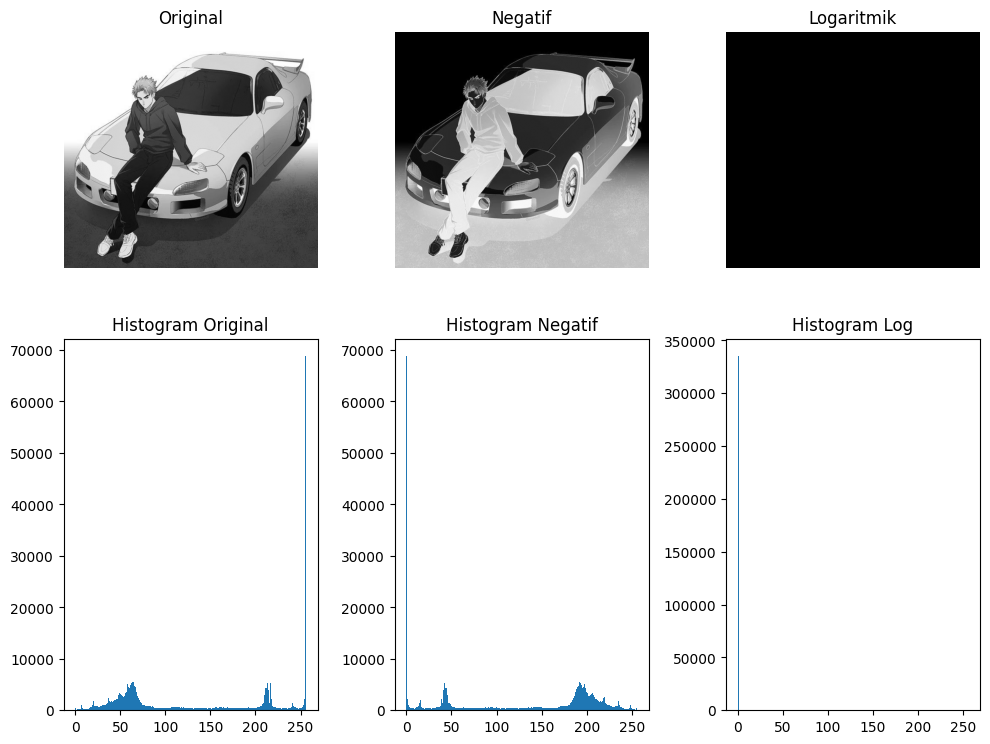

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar grayscale
img = cv2.imread('gambar.jpg', 0)  # pastikan file ada

# NEGATIF
negatif = 255 - img

# LOGARITMIK
c = 255 / np.log(1 + np.max(img))
log_img = c * np.log(1 + img)
log_img = np.array(log_img, dtype=np.uint8)

# Plot hasil
plt.figure(figsize=(10,8))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(negatif, cmap='gray')
plt.title('Negatif')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(log_img, cmap='gray')
plt.title('Logaritmik')
plt.axis('off')

# Histogram
plt.subplot(2,3,4)
plt.hist(img.ravel(), 256, [0,256])
plt.title('Histogram Original')

plt.subplot(2,3,5)
plt.hist(negatif.ravel(), 256, [0,256])
plt.title('Histogram Negatif')

plt.subplot(2,3,6)
plt.hist(log_img.ravel(), 256, [0,256])
plt.title('Histogram Log')

plt.tight_layout()
plt.show()

Mean Original: 139.05726105137396
Mean LPF: 139.05859916367982
Mean HPF: 18.013676821983275
Mean BPF: 138.79232676224612


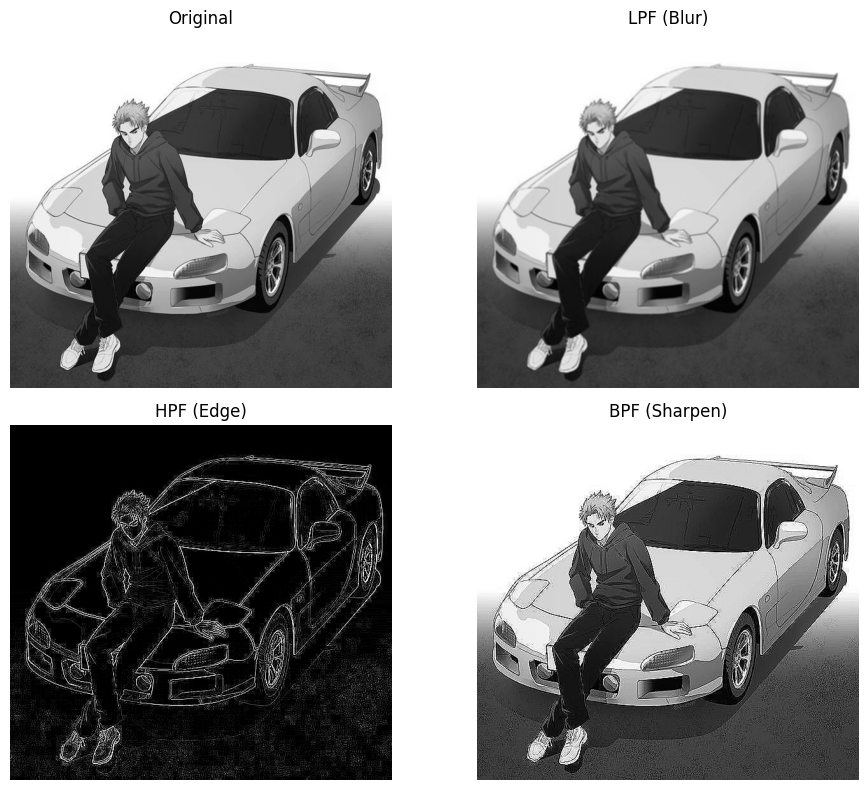

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('gambar.jpg', 0)

# Kernel
lpf = np.ones((3,3), np.float32) / 9
hpf = np.array([[-1,-1,-1],
                [-1, 8,-1],
                [-1,-1,-1]])
bpf = np.array([[0,-1,0],
                [-1,5,-1],
                [0,-1,0]])

# Konvolusi
img_lpf = cv2.filter2D(img, -1, lpf)
img_hpf = cv2.filter2D(img, -1, hpf)
img_bpf = cv2.filter2D(img, -1, bpf)

# Rata-rata pixel
print("Mean Original:", np.mean(img))
print("Mean LPF:", np.mean(img_lpf))
print("Mean HPF:", np.mean(img_hpf))
print("Mean BPF:", np.mean(img_bpf))

# Plot
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_lpf, cmap='gray')
plt.title('LPF (Blur)')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img_hpf, cmap='gray')
plt.title('HPF (Edge)')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img_bpf, cmap='gray')
plt.title('BPF (Sharpen)')
plt.axis('off')

plt.tight_layout()
plt.show()